# ANSYS Load Reconstruction Toolchain — Methodology Walkthrough

**Recovering applied loads from strain-gauge data via a finite-element strain sensitivity matrix.**

This notebook walks through, step by step, what each script in
`scripts/ansys_load_reconstruction/` actually does, why it does it, and the
structural-mechanics theory underneath. It is a self-contained companion to
`LOAD_RECONSTRUCTION_USER_GUIDE.md`.

### The problem in one line

We measure strains $S$ on an instrumented part and want the **applied loads** $L$ that caused them:

$$ S = A\,L + \varepsilon_{\text{err}} $$

- $S$ — measured strain history (one row per time point, one column per gauge channel)
- $A$ — **strain sensitivity matrix** from FE *unit-load* cases (rows = channels, cols = load components)
- $L$ — the load vector we want to estimate at each time point
- $\varepsilon_{\text{err}}$ — measurement error (noise, gage-factor, gauge mis-positioning, thermal, FE error)

This is a classic **inverse / force-identification problem**: the forward map $L\mapsto S$ is a cheap
FE calculation; recovering $L$ from $S$ is the hard, error-sensitive direction.

### What is runnable here

The steps that require a live ANSYS Mechanical session, DPF, and the benchmark `.wbpj` are shown as
**annotated excerpts of the real scripts** (they cannot run outside Mechanical). Every piece of
**mathematics** — building $A$, the local-strain projection, the placement gradient, the
least-squares solve, and the Monte-Carlo uncertainty — runs here on **synthetic data** so you can
see the mechanics end to end. Synthetic demos are clearly marked **▶ Runnable demo**.

## 1 · The pipeline at a glance

The toolchain is **four production scripts** plus **two inspection helpers**. The forward model is
built once per FE model; the inverse solve is run per measured strain record.

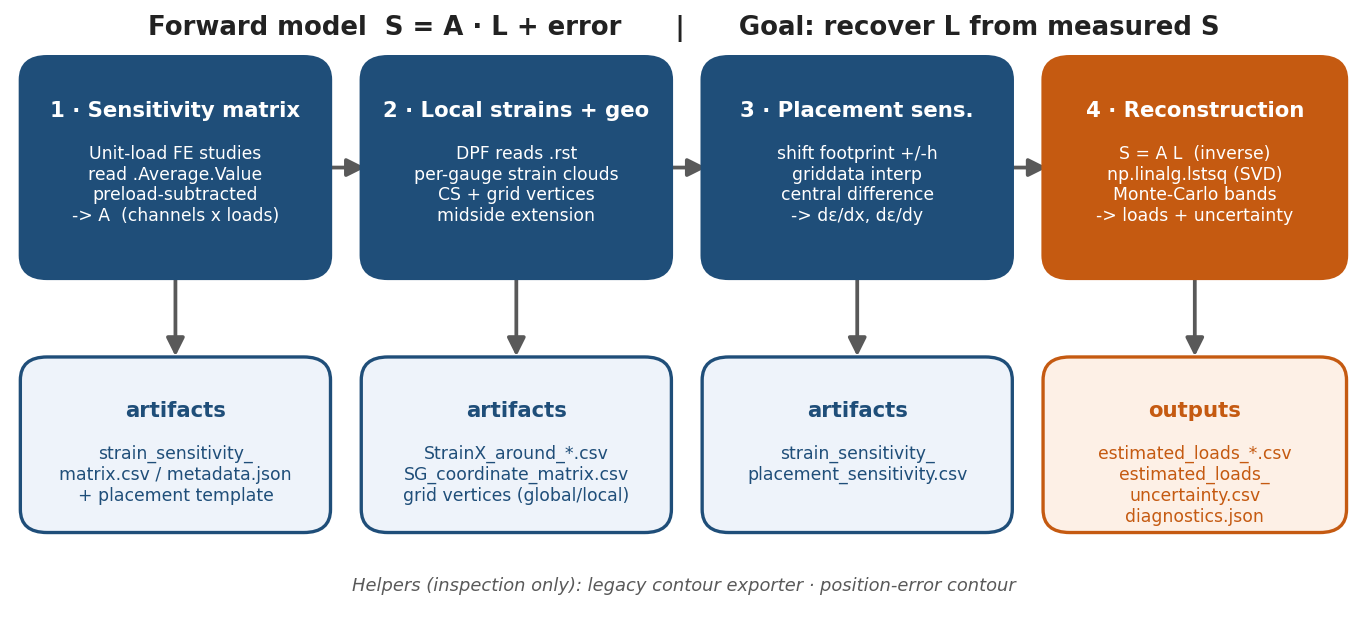

| # | Script | Runs in | Produces |
|---|--------|---------|----------|
| 1 | `get_strain_sensitivity_matrix_from_unit_load_cases_in_mechanical_v0.py` | Mechanical (IronPython) + spawned CPython | `strain_sensitivity_matrix.csv` (**A**), `strain_sensitivity_metadata.json`, placement template |
| 2 | `get_local_strains_and_SG_geo_data_around_each_SG_grid_dpf.py` *(preferred)* / `...grid.py` *(legacy)* | Mechanical + DPF | `StrainX_around_*.csv`, `SG_coordinate_matrix.csv`, grid vertices, DPF diagnostics |
| 3 | `calculate_placement_sensitivity_from_local_strains.py` | IronPython button + spawned CPython | `strain_sensitivity_placement_sensitivity.csv` ($\partial\varepsilon/\partial x,\ \partial\varepsilon/\partial y$) |
| 4 | `load_reconstruction_function_with_errors_weighting_function_v1.py` | IronPython + spawned CPython | `estimated_loads_*.csv`, `estimated_loads_uncertainty.csv`, `load_reconstruction_diagnostics.json` |
| H | `get_position_error_contour_v0.3.py` | Mechanical + spawned CPython | `SG_positioning_errors.csv` + in-Mechanical contour *(inspection only)* |

> **Execution pattern.** Mechanical runs user-button scripts in **IronPython**, which has no NumPy/SciPy.
> Each numeric script therefore writes a **CPython worker** to a temp file and launches the external
> `python.exe` for the array math. That two-layer (IronPython orchestrator → CPython worker) pattern
> recurs in scripts 1, 3, 4 and the helper.

## 2 · Theory primer

### Linear elastic superposition

The whole method rests on one assumption: within the operating envelope the structure is **linear
elastic**, so strain is a *linear* function of the applied loads. If unit load $j$ acting alone
produces strain $A_{ij}$ at channel $i$, then a combination $L=(L_1,\dots,L_n)$ produces

$$ \varepsilon_i = \sum_j A_{ij} L_j \quad\Longleftrightarrow\quad S = A\,L,\qquad A_{ij}=\frac{\partial \varepsilon_i}{\partial F_j}. $$

This holds when material behaviour is linear, deformations are small (linear strain–displacement),
contacts/supports/preload do not change with load, and the real loading lies in the **span** of the
chosen unit-load cases. Break these and least squares still returns numbers — just not meaningful ones.

### The inverse solve

With more gauges than loads ($m>n$) the system is overdetermined; we take the least-squares estimate

$$ \hat L = \arg\min_L \lVert A L - S\rVert_2 . $$

The code computes this with a **direct SVD** (`np.linalg.lstsq`), **not** the normal equations
$\hat L=(A^\top A)^{-1}A^\top S$. Forming $A^\top A$ *squares* the condition number, so the SVD path is
far more stable for near-collinear load bases.

### Conditioning

With $A=U\Sigma V^\top$, the condition number is $\kappa(A)=\sigma_{\max}/\sigma_{\min}$. A large
$\kappa$ means a tiny strain error can map to a huge load error — the benchmark model has
$\kappa\approx1.1\times10^{5}$. The point estimate is still the right baseline; you only add
regularization if real validation shows you need it.

In [1]:
# ▶ Runnable demo — build a benchmark-like A and inspect its conditioning
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260628)
N_CH, N_LD = 42, 3                      # 42 gauge channels, 3 load components (benchmark shape)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.35,
                     "axes.titleweight": "bold"})

# Construct A with prescribed singular values so kappa matches the benchmark (~1.1e5)
U, _ = np.linalg.qr(rng.standard_normal((N_CH, N_LD)))
V, _ = np.linalg.qr(rng.standard_normal((N_LD, N_LD)))
sv_true = np.array([3.0e-4, 7.0e-6, 2.7e-9])
A_bench = (U * sv_true) @ V.T

sv = np.linalg.svd(A_bench, compute_uv=False)
print("A shape          :", A_bench.shape)
print("singular values  :", sv)
print("rank             :", np.linalg.matrix_rank(A_bench))
print(f"condition number : kappa = {sv[0] / sv[-1]:.3e}")

A shape          : (42, 3)
singular values  : [3.0e-04 7.0e-06 2.7e-09]
rank             : 3
condition number : kappa = 1.111e+05


## 3 · Step 1 — Build the strain sensitivity matrix $A$

**Script:** `get_strain_sensitivity_matrix_from_unit_load_cases_in_mechanical_v0.py` (Mechanical IronPython)

### What it does

You set up **one analysis environment per unit load case**, each named `Unit_Load_Study_LC_*`. In
each, identical `StrainX_SG*` *Normal Elastic Strain* results are scoped to the matching
`SG_Grid_Body_*` shell body. The script:

1. Collects the `Unit_Load_Study_LC_*` analyses **in tree order** (this fixes the load-column order of $A$).
2. Pops a dialog to pick the **unit-load step** and the **preload/initial step**.
3. Reads each result's `NormalElasticStrain.Average.Value` at *both* steps.
4. **Subtracts** the preload-step strain from the unit-load-step strain — isolating the response of
   the unit load alone.
5. Writes $A$ (rows = channels, cols = load cases) to `strain_sensitivity_matrix.csv`, plus a metadata
   JSON, and a *template* placement CSV.
6. Spawns a CPython worker to add **rank, singular values, condition number** to the metadata via SVD.

### Why `.Average.Value` matters

Each `StrainX_SG*` result is scoped to a **finite shell grid body** (the modelled gauge footprint), so
`Average.Value` is already the *mean strain over the gauge grid* — not a point value. The matrix row is
therefore the finite-gauge average; **do not** apply a second averaging correction downstream.

### Why preload subtraction matters

Real turbine hardware sits in a preloaded state (bolt-up, interference fits, thermal soak) *before*
the load of interest. Reading strain at the unit-load step **minus** the preload step makes each
column of $A$ the *incremental* response to that unit load. Skip it and $A$ is contaminated by the
preload state, silently breaking the linearity the whole inversion depends on.

**Annotated excerpt** — the core extraction and preload subtraction (paraphrased from the script):

```python
# For each Unit_Load_Study_LC_* analysis, read the finite-grid AVERAGE strain ...
for analysis in unit_load_analyses:                    # tree order == column order of A
    for result in analysis.Solution.StrainX_SG_results:
        result.DisplayTime = Quantity(endtime_initial, "sec")   # preload state
analysis.Solution.EvaluateAllResults()
initial = [r.Maximum and r.Average.Value for r in results]      # .Average.Value == grid mean

for result in results:
    result.DisplayTime = Quantity(endtime_unit_load, "sec")     # unit-load state
analysis.Solution.EvaluateAllResults()
unit = [r.Average.Value for r in results]

# isolate the unit-load response  ->  one column of A
column = [u - i for u, i in zip(unit, initial)]
```

In [2]:
# ▶ Runnable demo — assemble A from (synthetic) .Average.Value readings, and show
#   why forgetting the preload subtraction corrupts the matrix.
n_demo_ch = 6
preload = rng.normal(0, 5e-4, n_demo_ch)            # gauge reads under preload only (same for all LCs)
true_response = rng.normal(0, 3e-4, (n_demo_ch, N_LD))   # the TRUE per-unit-load incremental strain

# what Mechanical reports at the unit-load step = preload + true response
unit_step_reading = preload[:, None] + true_response

A_correct = unit_step_reading - preload[:, None]    # preload-subtracted  (Step-1 logic)
A_wrong   = unit_step_reading                        # if you forget to subtract

print("preload-subtracted A reproduces the true response:",
      np.allclose(A_correct, true_response))
print(f"max |error| if preload is NOT subtracted: {np.abs(A_wrong - true_response).max():.2e} strain")
print(f"  (that is {np.abs(preload).max()/np.abs(true_response).max()*100:.0f}% of the signal — a systematic, load-independent corruption)")

preload-subtracted A reproduces the true response: True
max |error| if preload is NOT subtracted: 8.85e-04 strain
  (that is 134% of the signal — a systematic, load-independent corruption)


### Outputs of Step 1

| File | Meaning |
|------|---------|
| `strain_sensitivity_matrix.csv` | the matrix **A**, shape `channels × load_cases` (benchmark `42 × 3`), no header |
| `strain_sensitivity_metadata.json` | channel order, result/body names, scope evidence, shell/sheet evidence, **rank / singular values / condition number**, warnings |
| `strain_sensitivity_placement_sensitivity.csv` | *template* (rows `not_computed`) — filled later by Step 3 |

The benchmark matrix is full rank 3 with $\kappa\approx1.11\times10^{5}$. Below, a synthetic $A$ shows
the same structure: two load cases that excite the gauges *similarly* (near-collinear columns) drive
the small singular value — i.e. the conditioning.

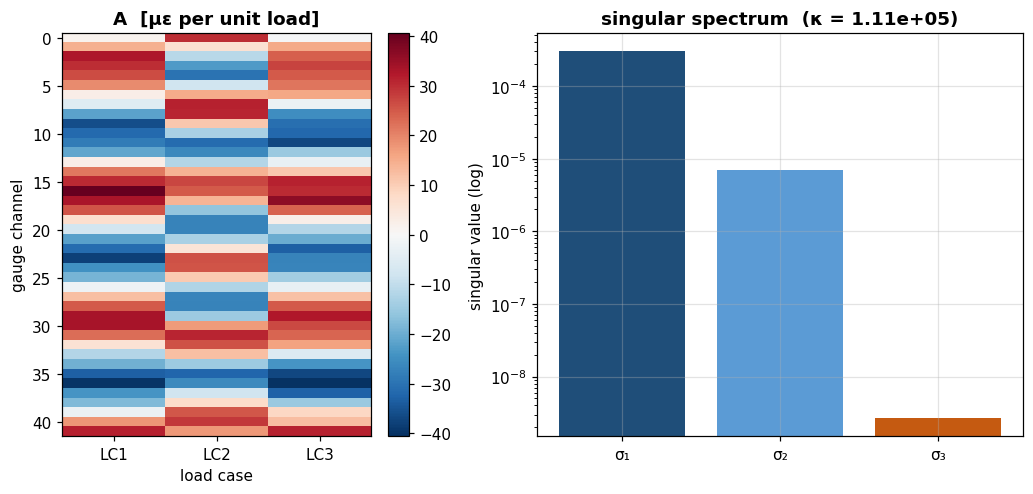

In [3]:
# ▶ Runnable demo — visualise A and its singular spectrum
ch = np.arange(N_CH)
p_a = 35e-6 * np.sin(2 * np.pi * ch / 13.0)
p_b = 30e-6 * np.cos(2 * np.pi * ch / 8.0 + 0.4)
A_heat = np.column_stack([p_a + rng.normal(0, 3e-6, N_CH),
                          p_b + rng.normal(0, 3e-6, N_CH),
                          0.92 * p_a + 0.12 * p_b + rng.normal(0, 3e-6, N_CH)])  # LC3 ~ LC1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.6), gridspec_kw={"width_ratios": [1, 1.4]})
im = ax1.imshow(A_heat * 1e6, aspect="auto", cmap="RdBu_r",
                vmin=-abs(A_heat * 1e6).max(), vmax=abs(A_heat * 1e6).max())
ax1.set(title="A  [µε per unit load]", xlabel="load case", ylabel="gauge channel",
        xticks=[0, 1, 2], xticklabels=["LC1", "LC2", "LC3"]); ax1.grid(False)
fig.colorbar(im, ax=ax1, fraction=0.06)

svh = np.linalg.svd(A_bench, compute_uv=False)
ax2.bar([1, 2, 3], svh, color=["#1f4e79", "#5b9bd5", "#c55a11"])
ax2.set(yscale="log", title=f"singular spectrum  (κ = {svh[0]/svh[-1]:.2e})",
        xticks=[1, 2, 3], xticklabels=["σ₁", "σ₂", "σ₃"], ylabel="singular value (log)")
plt.tight_layout(); plt.show()

## 4 · Step 2 — Export local strain fields + gauge geometry

**Preferred:** `get_local_strains_and_SG_geo_data_around_each_SG_grid_dpf.py` (DPF)
**Legacy:** `get_local_strains_and_SG_geo_data_around_each_SG_grid.py` (Mechanical contour objects)

### What it does

For each gauge channel it exports the **local strain cloud** (nodal strains within a radius of the
gauge), the gauge's **local coordinate system** `CS_SG_Ch_*`, and the `SG_Grid_Body_*` **vertices**
(global and rotated into the local frame). These feed Step 3's placement-gradient calculation.

The strain a gauge reads is the **normal strain along its own axis**. Given the full strain tensor at
a node and the gauge's local x-axis $\mathbf n=(x_0,x_1,x_2)$, that projection is the tensor
contraction $\varepsilon_n=\mathbf n^\top\varepsilon\,\mathbf n$:

$$ \varepsilon_x = \varepsilon_{xx}x_0^2 + \varepsilon_{yy}x_1^2 + \varepsilon_{zz}x_2^2
   + \gamma_{xy}x_0x_1 + \gamma_{yz}x_1x_2 + \gamma_{xz}x_0x_2 $$

(engineering-shear convention, single products). This is exactly `local_x_normal_strain` in the script.

**Annotated excerpt** — verbatim projection from the DPF script:

```python
def local_x_normal_strain(vector, x_axis):
    ex, ey, ez, gxy, gyz, gxz = [float(v) for v in vector[:6]]
    x0, x1, x2 = x_axis
    return (ex*x0*x0 + ey*x1*x1 + ez*x2*x2
            + gxy*x0*x1 + gyz*x1*x2 + gxz*x0*x2)
```

The DPF path reads nodal elastic-strain tensors directly from the `.rst` via the `elastic_strain`
operator, and for high-order (parabolic) elements fills the **midside nodes** with DPF's unscoped
`extend_to_mid_nodes_fc` — so the numbers match Mechanical's contour export. It is batch-driven by
`SG_LOCAL_DPF_*` environment variables and writes `local_sg_strain_dpf_diagnostics.json`.

gauge axis @   0°  ->    100.0 µε
gauge axis @  45°  ->     65.0 µε
gauge axis @  90°  ->    -30.0 µε


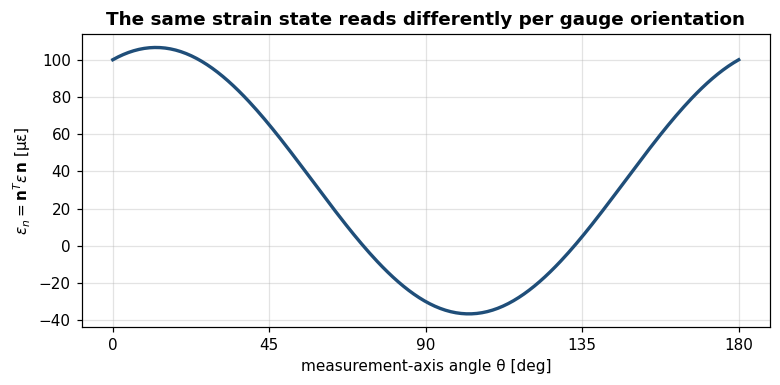

In [4]:
# ▶ Runnable demo — a gauge reads strain projected onto its axis (Mohr-like behaviour)
def local_x_normal_strain(vec, x_axis):
    ex, ey, ez, gxy, gyz, gxz = vec[:6]
    x0, x1, x2 = x_axis
    return ex*x0*x0 + ey*x1*x1 + ez*x2*x2 + gxy*x0*x1 + gyz*x1*x2 + gxz*x0*x2

eps = [100e-6, -30e-6, 10e-6, 60e-6, 0.0, 0.0]      # a plane-strain state [exx,eyy,ezz,gxy,gyz,gxz]
for ang in (0, 45, 90):
    a = np.deg2rad(ang); n = [np.cos(a), np.sin(a), 0.0]
    print(f"gauge axis @ {ang:3d}°  ->  {local_x_normal_strain(eps, n)*1e6:7.1f} µε")

th = np.linspace(0, np.pi, 240)
en = [local_x_normal_strain(eps, [np.cos(t), np.sin(t), 0.0]) for t in th]
plt.figure(figsize=(7.2, 3.6))
plt.plot(np.rad2deg(th), np.array(en)*1e6, color="#1f4e79", lw=2.2)
plt.xlabel("measurement-axis angle θ [deg]"); plt.ylabel(r"$\varepsilon_n=\mathbf{n}^T\varepsilon\,\mathbf{n}$ [µε]")
plt.title("The same strain state reads differently per gauge orientation")
plt.xticks([0, 45, 90, 135, 180]); plt.tight_layout(); plt.show()

In [5]:
# ▶ Runnable demo — rotate a global node cloud into a gauge's local frame
#   (this is how StrainX_around_*.csv node positions get expressed in CS_SG_Ch_*).
origin = np.array([10.0, 5.0, 0.0])
xax = np.array([np.cos(0.3), np.sin(0.3), 0.0]); xax /= np.linalg.norm(xax)
zax = np.array([0.0, 0.0, 1.0])
yax = np.cross(zax, xax)
R = np.vstack([xax, yax, zax])                       # rows are the local basis vectors

global_pts = rng.normal(0, 2.0, (5, 3)) + origin
local_pts = (global_pts - origin) @ R.T              # translate to origin, project onto local axes
print("global (mm):\n", global_pts.round(2))
print("\nlocal  (mm)  [x along gauge axis, y across, z out-of-plane]:\n", local_pts.round(2))

global (mm):
 [[11.38  5.19 -0.87]
 [12.1   6.55 -0.8 ]
 [11.89  3.78 -3.17]
 [10.89  7.31 -0.19]
 [ 9.39  5.64 -0.9 ]]

local  (mm)  [x along gauge axis, y across, z out-of-plane]:
 [[ 1.37 -0.22 -0.87]
 [ 2.46  0.86 -0.8 ]
 [ 1.45 -1.72 -3.17]
 [ 1.53  1.95 -0.19]
 [-0.39  0.8  -0.9 ]]


**DPF vs legacy** — same physics, different mechanics:

| Aspect | Legacy (`...grid.py`) | DPF (`...grid_dpf.py`) *(preferred)* |
|---|---|---|
| Method | creates temp named-selections + contour results, then `ExportToTextFile` | reads `.rst` directly via DPF operators |
| Speed | slower (tree updates, UI redraws) | fast (no tree objects) |
| Batch | interactive prompts | `SG_LOCAL_DPF_*` env vars |
| Midside nodes | Mechanical-implicit | explicit `extend_to_mid_nodes_fc` |
| Diagnostics | none | `local_sg_strain_dpf_diagnostics.json` |

Both write identical CSVs: `StrainX_around_*.csv`, `SG_coordinate_matrix.csv`,
`SG_grid_body_vertices.csv`, `SG_grid_body_vertices_in_local_CS.csv`.

## 5 · Step 3 — Placement sensitivity (spatial strain gradient)

**Script:** `calculate_placement_sensitivity_from_local_strains.py` (IronPython button + CPython worker)

### What it does

A bonded gauge can only be placed to finite accuracy. If its footprint shifts by $(\Delta x,\Delta y)$
in its local plane, the *measured* (footprint-averaged) strain changes by

$$ \Delta\varepsilon \approx \frac{\partial\bar\varepsilon}{\partial x}\Delta x
   + \frac{\partial\bar\varepsilon}{\partial y}\Delta y . $$

So the script needs the **spatial gradient of the footprint-averaged strain**. For each channel it:

1. Rotates the exported node cloud into the gauge's `CS_SG_Ch_*` frame.
2. Interpolates the local strain onto a regular grid over the gauge footprint
   (`scipy.interpolate.griddata`, *linear* with *nearest-neighbour* fill; least-squares plane fallback).
3. **Rigidly shifts** the whole footprint by $\pm h$ ($h=0.1$ mm default) in local $x$ and $y$ and
   re-averages.
4. **Central-differences** the footprint mean:
   $$ g_x=\frac{\bar\varepsilon(+h)-\bar\varepsilon(-h)}{2h},\qquad
      g_y=\frac{\bar\varepsilon(0,+h)-\bar\varepsilon(0,-h)}{2h}. $$

Output columns: `d_epsilon_d_x_per_mm`, `d_epsilon_d_y_per_mm`, `gradient_norm_per_mm`, per
(channel, load case). The $\pm0.1$ mm is a *derivative step*, not the placement uncertainty itself —
the actual uncertainty (mm) is supplied later, in Step 4.

**Annotated excerpt** — verbatim central-difference core:

```python
def derivatives_for_channel(local_xy, strain, bounds, step_mm, nx, ny):
    px, *_ = averaged_strain(local_xy, strain, bounds, +step_mm, 0.0, nx, ny)
    mx, *_ = averaged_strain(local_xy, strain, bounds, -step_mm, 0.0, nx, ny)
    py, *_ = averaged_strain(local_xy, strain, bounds, 0.0, +step_mm, nx, ny)
    my, *_ = averaged_strain(local_xy, strain, bounds, 0.0, -step_mm, nx, ny)
    gx = (px - mx) / (2.0 * step_mm)
    gy = (py - my) / (2.0 * step_mm)
    return gx, gy, ...
```
where `averaged_strain` interpolates onto the (shifted) footprint grid and returns the mean.

d eps/dx =  22.00 µε/mm   (analytic ∂/∂x at origin = 22.0)
d eps/dy =   6.00 µε/mm   (analytic ∂/∂y at origin =  6.0)


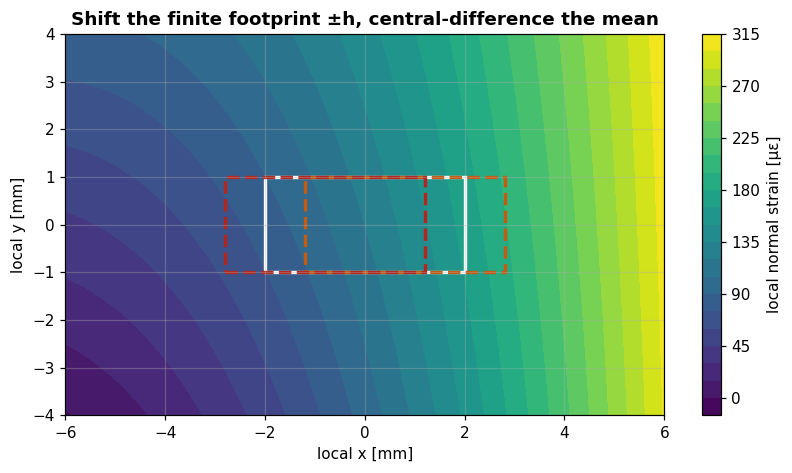

In [6]:
# ▶ Runnable demo — reproduce the finite-footprint central difference on an analytic field
def field(x, y):                       # smooth local strain field [µε] with a real gradient
    return 120 + 22*x + 6*y + 1.5*x**2 - 0.8*x*y

def footprint_mean(cx, cy, hw=2.0, hh=1.0, nx=11, ny=5):
    xs = np.linspace(cx - hw, cx + hw, nx)
    ys = np.linspace(cy - hh, cy + hh, ny)
    gx, gy = np.meshgrid(xs, ys)
    return field(gx, gy).mean()

h = 0.1
gx = (footprint_mean(+h, 0) - footprint_mean(-h, 0)) / (2 * h)
gy = (footprint_mean(0, +h) - footprint_mean(0, -h)) / (2 * h)
print(f"d eps/dx = {gx:6.2f} µε/mm   (analytic ∂/∂x at origin = 22.0)")
print(f"d eps/dy = {gy:6.2f} µε/mm   (analytic ∂/∂y at origin =  6.0)")

# visualise the field + nominal/shifted footprints
xs = np.linspace(-6, 6, 200); ys = np.linspace(-4, 4, 160)
GX, GY = np.meshgrid(xs, ys)
plt.figure(figsize=(7.6, 4.4))
cf = plt.contourf(GX, GY, field(GX, GY), levels=22, cmap="viridis")
plt.colorbar(cf, label="local normal strain [µε]")
H = 0.8                                  # exaggerated for visibility (real default 0.1)
for dx, col, ls in [(0, "white", "-"), (+H, "#c55a11", "--"), (-H, "#b3261e", "--")]:
    plt.gca().add_patch(plt.Rectangle((dx-2, -1), 4, 2, fill=False, edgecolor=col, lw=2.2, ls=ls))
plt.title("Shift the finite footprint ±h, central-difference the mean")
plt.xlabel("local x [mm]"); plt.ylabel("local y [mm]"); plt.tight_layout(); plt.show()

## 6 · Step 4 — Reconstruct the loads

**Script:** `load_reconstruction_function_with_errors_weighting_function_v1.py` (IronPython + CPython worker)

### What it does

Given the measured strains `SG_FEA_strain_data.csv` and the sensitivity matrix `strain_sensitivity_matrix.csv`,
it solves the least-squares problem **per time point** with a direct SVD, writes the point estimate,
then runs a **Monte-Carlo** uncertainty propagation. Despite the legacy filename, the error inputs do
**not** change the point estimate — they only drive the uncertainty bands.

**Annotated excerpt** — verbatim solve and conditioning (the heart of the script):

```python
solution, residuals, rank, singular_values = np.linalg.lstsq(A_matrix, S_matrix.T, rcond=None)
L_hat_timeseries = solution.T
predicted_strain = L_hat_timeseries @ A_matrix.T
residual_matrix  = S_matrix - predicted_strain
condition_number = singular_values[0] / singular_values[-1]
```

max |recovery error|, clean : 1.33e-15
max |recovery error|, +20µε : 1.216


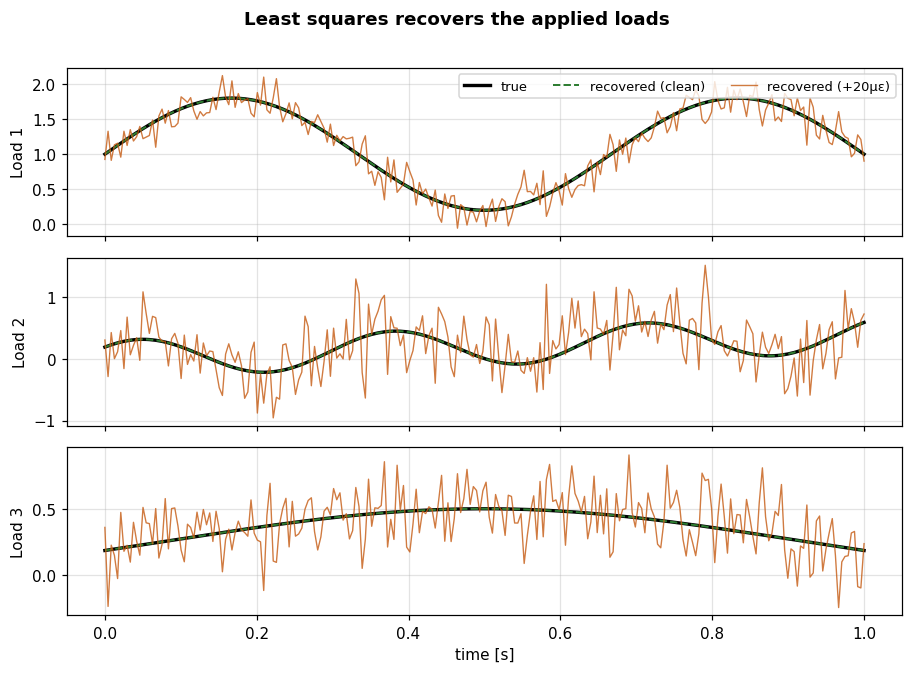

In [7]:
# ▶ Runnable demo — forward-simulate strains from known loads, then recover them
svd = np.array([3.0e-4, 1.2e-4, 4.5e-5])             # well-conditioned illustrative A (κ≈7)
A = (U * svd) @ V.T
t = np.linspace(0.0, 1.0, 240)
L_true = np.column_stack([
    1.0 + 0.8*np.sin(2*np.pi*1.5*t),                 # Load 1
    0.4*t + 0.3*np.sin(2*np.pi*3.0*t + 0.7),         # Load 2
    0.6*np.exp(-3*(t - 0.5)**2) - 0.1,               # Load 3
])
S = (A @ L_true.T).T                                  # forward model: clean strains
S_noisy = S + rng.normal(0, 20e-6, S.shape)          # add 20 µε measurement noise

L_hat       = np.linalg.lstsq(A, S.T,       rcond=None)[0].T
L_hat_noisy = np.linalg.lstsq(A, S_noisy.T, rcond=None)[0].T
print(f"max |recovery error|, clean : {np.abs(L_hat - L_true).max():.2e}")
print(f"max |recovery error|, +20µε : {np.abs(L_hat_noisy - L_true).max():.3f}")

fig, axes = plt.subplots(3, 1, figsize=(8.4, 6.2), sharex=True)
for k, ax in enumerate(axes):
    ax.plot(t, L_true[:, k], "k", lw=2.2, label="true")
    ax.plot(t, L_hat[:, k], "--", color="#2e7d32", lw=1.3, label="recovered (clean)")
    ax.plot(t, L_hat_noisy[:, k], color="#c55a11", lw=0.9, alpha=0.8, label="recovered (+20µε)")
    ax.set_ylabel(f"Load {k+1}")
    if k == 0: ax.legend(ncol=3, fontsize=8.5, loc="upper right")
axes[-1].set_xlabel("time [s]"); fig.suptitle("Least squares recovers the applied loads", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

In [8]:
# ▶ Runnable demo — conditioning controls noise amplification.
#   Build matrices with a PRESCRIBED, increasing condition number (full rank, all
#   singular values well above lstsq's truncation floor) and apply the SAME 20 µε noise.
#   (A numerically-singular basis would instead be silently min-norm-regularised by
#    lstsq's SVD truncation — so we stay in the genuinely ill-conditioned regime.)
def A_with_cond(kappa):
    sv = np.array([3.0e-4, 3.0e-4 / np.sqrt(kappa), 3.0e-4 / kappa])   # prescribed spectrum
    return (U * sv) @ V.T

print(f"{'kappa(A)':>12} | {'max |load error| @ 20 ue noise':>32}")
print("-" * 49)
for kappa in [1e1, 1e2, 1e3, 1e4]:
    Ak = A_with_cond(kappa)
    Sk = (Ak @ L_true.T).T + rng.normal(0, 20e-6, S.shape)             # forward + same-sigma noise
    Lk = np.linalg.lstsq(Ak, Sk.T, rcond=None)[0].T
    print(f"{np.linalg.cond(Ak):12.1e} | {np.abs(Lk - L_true).max():32.3f}")
print("\nHigher kappa -> the same strain noise maps to a larger load error.")

    kappa(A) |   max |load error| @ 20 ue noise
-------------------------------------------------
     1.0e+01 |                            1.946
     1.0e+02 |                           18.291
     1.0e+03 |                          213.275
     1.0e+04 |                         1822.246

Higher kappa -> the same strain noise maps to a larger load error.


### Outputs of Step 4

| File | Meaning |
|------|---------|
| `estimated_loads_with_errors_per_gauge_RMS.csv` | the point estimate $\hat L(t)$ (legacy name; **unaffected** by error inputs) |
| `estimated_loads_uncertainty.csv` | per load: `Mean`, `Std`, `P2.5`, `P97.5` from Monte Carlo |
| `load_reconstruction_diagnostics.json` | **first file to check** — shapes, rank, singular values, $\kappa$, residual RMS, warnings |
| `load_reconstruction_validation.csv` | written only if `known_loads.csv` is supplied (Known / Estimated / Error per load) |

## 7 · Uncertainty propagation (Monte Carlo)

The point estimate is pure least squares. **Three error sources** are propagated by perturbing the
*measured strain* and re-solving, $N$ times (default 1000, seed `20260628`):

1. **Additive signal noise** — independent per (time, channel):
   $\;\varepsilon^{*}=\varepsilon+\mathcal N(0,\sigma_{\text{noise}}^2)$, with $\sigma_{\text{noise}}$
   the GUI microstrain value $\times10^{-6}$.
2. **Gage-factor error** — *systematic, multiplicative, per channel, held over the whole record*:
   $\;\varepsilon^{*}=\varepsilon\,(1+\mathcal N(0,\sigma_{\text{gage}}^2))$.
3. **Positioning error** — *gradient-driven*:
   $\;\Delta\varepsilon=\dfrac{\partial\varepsilon}{\partial x}\,dx+\dfrac{\partial\varepsilon}{\partial y}\,dy$,
   with $dx,dy\sim\mathcal N(0,\sigma_{\text{pos}}^2)$ per channel.

The elegant part: the per-load placement gradients (channels × loads) are mapped to a per-channel
strain rate by the **current load estimate** — `dstrain_dx = L_hat @ placement_gx.T`. So the
positioning-induced strain error automatically **scales with how hard the structure is driven** at
each instant, then flows back through the same `lstsq` to give the load band.

**Annotated excerpt** — verbatim Monte-Carlo body:

```python
for sample_index in range(MONTE_CARLO_SAMPLES):
    strain_sample = np.array(S_matrix, copy=True)
    strain_sample += rng.normal(0.0, noise_sigma, size=strain_sample.shape)         # (1) noise
    channel_scale = 1.0 + rng.normal(0.0, gage_factor_sigma, size=n_channels)        # (2) gage factor
    strain_sample *= channel_scale.reshape((1, -1))
    dx = rng.normal(0.0, POSITIONING_STD_MM, size=n_channels)                        # (3) positioning
    dy = rng.normal(0.0, POSITIONING_STD_MM, size=n_channels)
    dstrain_dx = L_hat_timeseries @ placement_gx.T
    dstrain_dy = L_hat_timeseries @ placement_gy.T
    strain_sample += dstrain_dx * dx + dstrain_dy * dy
    samples[sample_index] = np.linalg.lstsq(A_matrix, strain_sample.T, rcond=None)[0].T
```

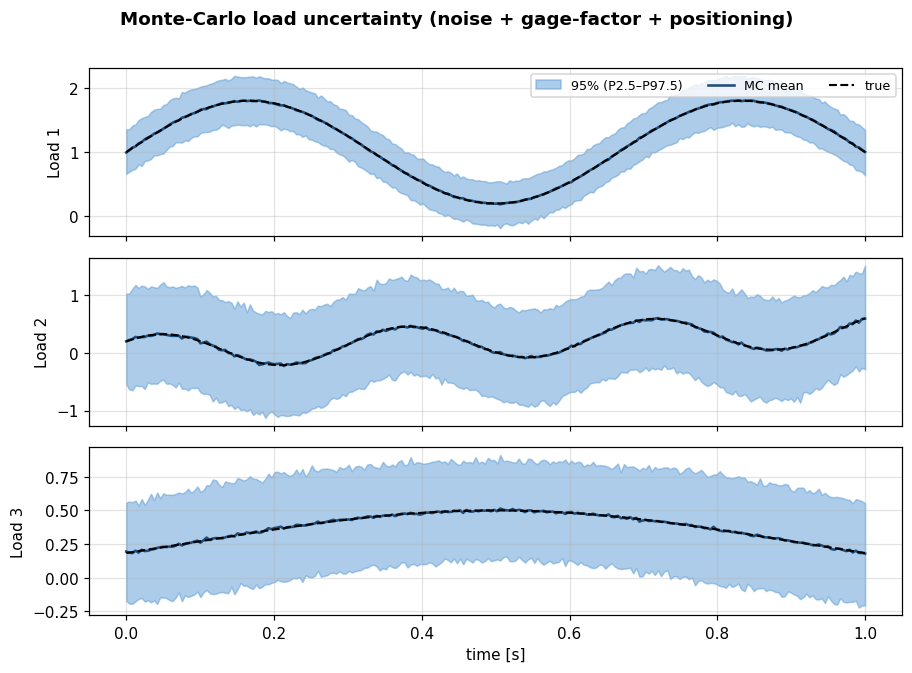

In [9]:
# ▶ Runnable demo — propagate all three error sources and plot the 95% band
placement_gx = rng.normal(0, 8e-6, (N_CH, N_LD))     # per-load ∂ε/∂x  (from Step 3 in practice)
placement_gy = rng.normal(0, 8e-6, (N_CH, N_LD))

n_mc = 1000
noise_sigma, gage_sigma, pos_sigma = 20e-6, 0.01, 0.5     # 20 µε, 1 %, 0.5 mm  (the GUI defaults)
samples = np.empty((n_mc, len(t), N_LD))
mc_rng = np.random.default_rng(7)
for i in range(n_mc):
    s = S + mc_rng.normal(0, noise_sigma, S.shape)
    s *= (1.0 + mc_rng.normal(0, gage_sigma, N_CH)).reshape(1, -1)
    dx = mc_rng.normal(0, pos_sigma, N_CH); dy = mc_rng.normal(0, pos_sigma, N_CH)
    s += (L_hat @ placement_gx.T) * dx + (L_hat @ placement_gy.T) * dy
    samples[i] = np.linalg.lstsq(A, s.T, rcond=None)[0].T

p025, p975 = np.percentile(samples, [2.5, 97.5], axis=0)
mean = samples.mean(axis=0)

fig, axes = plt.subplots(3, 1, figsize=(8.4, 6.2), sharex=True)
for k, ax in enumerate(axes):
    ax.fill_between(t, p025[:, k], p975[:, k], color="#5b9bd5", alpha=0.5, label="95% (P2.5–P97.5)")
    ax.plot(t, mean[:, k], color="#1f4e79", lw=1.7, label="MC mean")
    ax.plot(t, L_true[:, k], "k--", lw=1.4, label="true")
    ax.set_ylabel(f"Load {k+1}")
    if k == 0: ax.legend(ncol=3, fontsize=8.3, loc="upper right")
axes[-1].set_xlabel("time [s]")
fig.suptitle("Monte-Carlo load uncertainty (noise + gage-factor + positioning)", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

### Thermal / apparent strain — the silent trap

The solver only knows $S=A\,L$. A load-independent **thermal/apparent strain** present in $S$ has no
business being a mechanical load, but least squares will happily project it onto the load basis and
report **fake load**. If the model includes `Isothermal Heating` and no compensation file is supplied,
the diagnostics warn explicitly. Supply `SG_thermal_apparent_strain_data.csv`; its values are
subtracted from $S$ before solving.

fake load injected (Load 1 mean shift): -0.161
after compensation, max |error|       : 1.33e-15


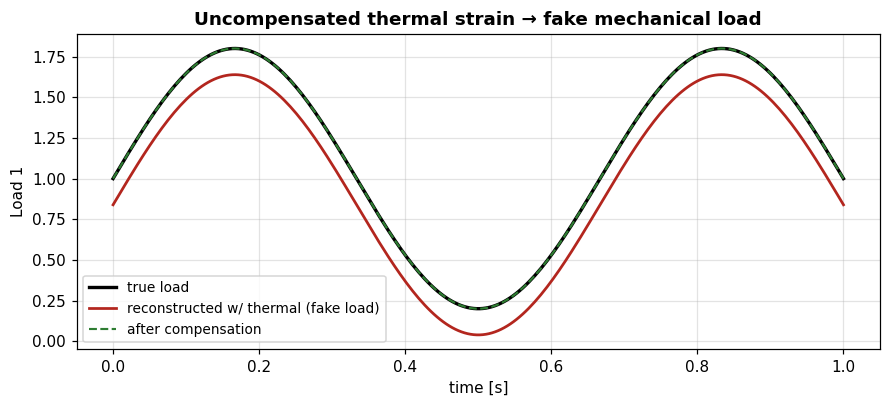

In [10]:
# ▶ Runnable demo — thermal strain reconstructs as fake load until compensated
thermal = np.full(N_CH, 60e-6)                       # apparent/thermal strain offset per channel
S_meas = S + thermal                                  # contaminated measurement
L_bias = np.linalg.lstsq(A, S_meas.T,           rcond=None)[0].T
L_comp = np.linalg.lstsq(A, (S_meas - thermal).T, rcond=None)[0].T
print(f"fake load injected (Load 1 mean shift): {(L_bias[:,0]-L_true[:,0]).mean():+.3f}")
print(f"after compensation, max |error|       : {np.abs(L_comp-L_true).max():.2e}")

plt.figure(figsize=(8.2, 3.8))
plt.plot(t, L_true[:, 0], "k", lw=2.2, label="true load")
plt.plot(t, L_bias[:, 0], color="#b3261e", lw=1.8, label="reconstructed w/ thermal (fake load)")
plt.plot(t, L_comp[:, 0], "--", color="#2e7d32", lw=1.4, label="after compensation")
plt.xlabel("time [s]"); plt.ylabel("Load 1"); plt.legend(fontsize=9)
plt.title("Uncompensated thermal strain → fake mechanical load"); plt.tight_layout(); plt.show()

## 8 · Helper — position error contour (inspection only)

**Script:** `get_position_error_contour_v0.3.py`

For each reference gauge (`CS_SG_Ch_*_2`) it finds the nearest mesh node to the reference position and
maps, for every node within a user radius, the **difference** in a selected result field — producing a
spatial "how wrong would I be if the gauge sat here instead" map (`SG_positioning_errors.csv`,
`SG_max_positioning_errors.csv`, and an optional in-Mechanical CSV-Plot contour).

> **Important:** this is for **visual inspection**, *not* the source of reconstruction placement
> sensitivity. It does **not** shift each finite gauge footprint in the channel's local frame — that
> is Step 3's job. Use Step 3's `strain_sensitivity_placement_sensitivity.csv` for uncertainty.

## 9 · Diagnostics, validation & trust checklist

`load_reconstruction_diagnostics.json` is the first place to look. Before trusting reconstructed loads:

1. `load_reconstruction_diagnostics.json` exists.
2. `normal_equations_used` is `false`.
3. `rank` equals the number of load columns.
4. `condition_number` is not unexpectedly large for your application.
5. `metadata_confirms_shell_channel_average` is `true` when metadata is present.
6. No channel-order warning appears.
7. If thermal loading exists, a thermal compensation file is supplied.
8. If positioning uncertainty matters, placement derivatives are numeric (not `not_computed`).
9. If possible, `known_loads.csv` validation error is acceptable.

## 10 · File & parameter reference

### Inputs

| File | Consumed by | Notes |
|------|-------------|-------|
| `strain_sensitivity_matrix.csv` | Step 4 | the matrix **A** (no header) |
| `SG_FEA_strain_data.csv` | Step 4 | `Time [s]` + one column per channel, **strain units** (not µε); channel order must match A |
| `strain_sensitivity_placement_sensitivity.csv` | Step 4 | placement gradients (only used if positioning σ > 0) |
| `SG_thermal_apparent_strain_data.csv` | Step 4 | optional thermal/apparent strain to subtract |
| `known_loads.csv` | Step 4 | optional validation (`Load 1, Load 2, …`) |
| `StrainX_around_*.csv`, `SG_coordinate_matrix.csv`, grid vertices | Step 3 | from Step 2 |

### Step-4 GUI / batch parameters (defaults)

| GUI field / env var | Default | Role |
|---|---|---|
| Overall Signal Noise (µε) / `SG_LOAD_RECON_SIGNAL_NOISE_MICROSTRAINS` | 20 | additive noise σ |
| Gage Factor Error (%) / `SG_LOAD_RECON_GAGE_FACTOR_ERROR_PERCENT` | 1 | systematic per-channel σ |
| Positioning Std. Uncertainty [mm] / `SG_LOAD_RECON_POSITION_STD_MM` | 0.5 | placement σ |
| `SG_LOAD_RECON_MONTE_CARLO_SAMPLES` | 1000 | MC samples |
| `SG_LOAD_RECON_SEED` | 20260628 | RNG seed |
| `SG_LOAD_RECON_NO_GUI`, `_NO_PLOT`, `_WAIT` | unset | batch flags |

Step-2 (DPF) batch: `SG_LOCAL_DPF_RADIUS_MM`, `_TIME_SEC`, `_PRELOAD_TIME_SEC`, `_WORKING_DIR`,
`_ANALYSIS_NAME`. Step-3: `SG_PLACEMENT_FINITE_DIFF_MM`, `_SAMPLES_X`, `_SAMPLES_Y`, `SG_PLACEMENT_PYTHON`.

## 11 · Limitations & closing

The method does **not** automatically handle:

- nonlinear material, geometry, or contact behaviour (breaks $S=A\,L$);
- real loading outside the span of the unit-load basis;
- FE model error baked into $A$;
- transverse-sensitivity correction of gauges;
- physical calibration against known loads;
- regularization-parameter selection;
- missing or incorrect gauge scoping.

**Bottom line.** The forward model $S=A\,L$ plus an SVD least-squares inverse is a clean, defensible
baseline. Its accuracy is governed by (a) how well the unit-load basis spans the real loading, (b) the
conditioning of $A$, and (c) honest accounting of noise, gage-factor, positioning, and thermal effects.
Validate against known loads whenever you can.

---
*Generated walkthrough — synthetic demos are illustrative; production runs require a live ANSYS
Mechanical session, DPF, and the project `.wbpj`. See `LOAD_RECONSTRUCTION_USER_GUIDE.md`.*